# TCREmp 10x dcode Analysis

This notebook reproduces a comprehensive 10x dcode workflow with CITE-seq integration:
- load donor-level paired VDJ plus binarized CITE-seq matrix into `SingleCellSample`;
- sanity-check binder definitions against VDJdb records with 10x references;
- derive donor1 pseudo-labels from positive binder channels;
- run TRA/TRB/TRA_TRB embeddings with PCA, k-nearest-neighbor eps diagnostics, and UMAP views;
- compute epitope-level classification scores.

Curation note:
- `KLGGALQAK` is excluded from donor-level modeling in this notebook based on personal communication from 10x indicating this dcode target can be somewhat spurious for this setting.

In [1]:
# Set deterministic seed, display settings, and print environment versions used in this analysis.
from __future__ import annotations

import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import sklearn
import umap
from IPython.display import display

from mir.common.single_cell import (
    load_10x_vdj_v1_citeseq_sample,
    validate_citeseq_binders_against_vdjdb_10x,
)
from mir.embedding.tcremp import PairedTCREmp
from mir.utils.embedding_diagnostics import (
    analyze_embedding_dbscan,
    classification_scores_by_label,
    majority_vote_cluster_predictions,
)
from mir.utils.notebook_assets import (
    ensure_airr_benchmark,
    find_airr_benchmark_dcode_10x_vdj_v1_donor,
    find_airr_benchmark_dcode_10x_vdj_v1_donor_matrix,
    find_airr_benchmark_vdjdb_full,
    find_repo_root,
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Exclude dcode epitopes with known curation caveats for this analysis pass.
EXCLUDED_EPITOPES = {'KLGGALQAK'}

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 140
plt.rcParams['savefig.dpi'] = 300

print(f'Python: {__import__("sys").version.split()[0]}')
print(f'numpy: {np.__version__}')
print(f'polars: {pl.__version__}')
print(f'pandas: {pd.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'umap-learn: {umap.__version__}')
print(f'Excluded epitopes in donor modeling: {sorted(EXCLUDED_EPITOPES)}')

/Users/mikesh/vcs/mirpy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.12.12
numpy: 1.26.4
polars: 1.40.1
pandas: 3.0.3
scikit-learn: 1.8.0
umap-learn: 0.5.12
Excluded epitopes in donor modeling: ['KLGGALQAK']


In [2]:
# Load AIRR benchmark assets and build SingleCellSample objects for all 10x_vdj_v1 donors.
repo_root = find_repo_root(Path.cwd())
dataset_root = ensure_airr_benchmark(repo_root=repo_root, allow_patterns=['dcode/*', 'vdjdb/**'])
vdjdb_full = find_airr_benchmark_vdjdb_full(dataset_root)

donor_ids = ['donor1', 'donor2', 'donor3', 'donor4']
samples = {}
donor_paths = {}

for donor_id in donor_ids:
    all_contig, consensus = find_airr_benchmark_dcode_10x_vdj_v1_donor(dataset_root, donor_id)
    matrix = find_airr_benchmark_dcode_10x_vdj_v1_donor_matrix(dataset_root, donor_id)
    donor_paths[donor_id] = {'all_contig': all_contig, 'consensus': consensus, 'matrix': matrix}
    t0 = time.perf_counter()
    sample = load_10x_vdj_v1_citeseq_sample(
        consensus_annotations_path=consensus,
        all_contig_annotations_path=all_contig,
        binarized_matrix_path=matrix,
        sample_id=donor_id,
    )
    dt = time.perf_counter() - t0
    samples[donor_id] = sample
    print(
        f'{donor_id}: cells={sample.paired_repertoire.loaded_cell_count:,} '
        f'pairs={sample.paired_repertoire.paired_locus_repertoires["TRA_TRB"].clonotype_count:,} '
        f'matrix_rows={sample.cite_seq_matrix.height:,} binder_cols={sample.cite_seq_binder_columns.height:,} '
        f'time={dt:.2f}s'
    )

donor1: cells=47,271 pairs=48,890 matrix_rows=46,526 binder_cols=78 time=1.12s


donor2: cells=79,704 pairs=72,266 matrix_rows=77,854 binder_cols=78 time=1.77s


donor3: cells=38,095 pairs=39,518 matrix_rows=37,824 binder_cols=78 time=1.13s


donor4: cells=27,640 pairs=29,147 matrix_rows=27,308 binder_cols=78 time=0.68s


In [3]:
# Validate donor binder definitions against VDJdb records annotated with 10x references.
sanity_rows = []
for donor_id, sample in samples.items():
    missing = validate_citeseq_binders_against_vdjdb_10x(sample.cite_seq_binder_columns, vdjdb_full)
    sanity_rows.append({
        'donor_id': donor_id,
        'binder_columns': sample.cite_seq_binder_columns.height,
        'missing_targets_vs_vdjdb_10x': missing.height,
    })
    if missing.height > 0:
        print(f'\n{donor_id} residual unmatched targets:')
        print(missing)

sanity_df = pl.DataFrame(sanity_rows).sort('donor_id')
print(sanity_df)


donor1 residual unmatched targets:
shape: (2, 5)
┌─────────────────────────────────┬───────┬─────────────────┬──────────────┬─────────────────┐
│ column                          ┆ hla   ┆ antigen.epitope ┆ antigen.gene ┆ antigen.species │
│ ---                             ┆ ---   ┆ ---             ┆ ---          ┆ ---             │
│ str                             ┆ str   ┆ str             ┆ str          ┆ str             │
╞═════════════════════════════════╪═══════╪═════════════════╪══════════════╪═════════════════╡
│ A0201_CLGGLLTMV_LMP-2A_EBV      ┆ A0201 ┆ CLGGLLTMV       ┆ LMP-2A       ┆ EBV             │
│ A0201_LLMGTLGIVC_HPV-16E7_82-9… ┆ A0201 ┆ LLMGTLGIVC      ┆ HPV-16E7     ┆ 82-91           │
└─────────────────────────────────┴───────┴─────────────────┴──────────────┴─────────────────┘

donor2 residual unmatched targets:
shape: (2, 5)
┌─────────────────────────────────┬───────┬─────────────────┬──────────────┬─────────────────┐
│ column                          ┆ hla   ┆ a


donor3 residual unmatched targets:
shape: (2, 5)
┌─────────────────────────────────┬───────┬─────────────────┬──────────────┬─────────────────┐
│ column                          ┆ hla   ┆ antigen.epitope ┆ antigen.gene ┆ antigen.species │
│ ---                             ┆ ---   ┆ ---             ┆ ---          ┆ ---             │
│ str                             ┆ str   ┆ str             ┆ str          ┆ str             │
╞═════════════════════════════════╪═══════╪═════════════════╪══════════════╪═════════════════╡
│ A0201_CLGGLLTMV_LMP-2A_EBV      ┆ A0201 ┆ CLGGLLTMV       ┆ LMP-2A       ┆ EBV             │
│ A0201_LLMGTLGIVC_HPV-16E7_82-9… ┆ A0201 ┆ LLMGTLGIVC      ┆ HPV-16E7     ┆ 82-91           │
└─────────────────────────────────┴───────┴─────────────────┴──────────────┴─────────────────┘



donor4 residual unmatched targets:
shape: (2, 5)
┌─────────────────────────────────┬───────┬─────────────────┬──────────────┬─────────────────┐
│ column                          ┆ hla   ┆ antigen.epitope ┆ antigen.gene ┆ antigen.species │
│ ---                             ┆ ---   ┆ ---             ┆ ---          ┆ ---             │
│ str                             ┆ str   ┆ str             ┆ str          ┆ str             │
╞═════════════════════════════════╪═══════╪═════════════════╪══════════════╪═════════════════╡
│ A0201_CLGGLLTMV_LMP-2A_EBV      ┆ A0201 ┆ CLGGLLTMV       ┆ LMP-2A       ┆ EBV             │
│ A0201_LLMGTLGIVC_HPV-16E7_82-9… ┆ A0201 ┆ LLMGTLGIVC      ┆ HPV-16E7     ┆ 82-91           │
└─────────────────────────────────┴───────┴─────────────────┴──────────────┴─────────────────┘
shape: (4, 3)
┌──────────┬────────────────┬──────────────────────────────┐
│ donor_id ┆ binder_columns ┆ missing_targets_vs_vdjdb_10x │
│ ---      ┆ ---            ┆ ---                     

In [4]:
# Build donor1 paired clonotype labels from positive CITE-seq binder channels.
# Deduplicate by paired (TRA + TRB) ntvj combination so each unique clonotype
# is counted once — cells sharing the same paired amino-acid sequence are pooled.
def donor1_binder_labels(sample):
    binder_cols = sample.cite_seq_binder_columns.filter(pl.col('is_binder') == '1').get_column('column').to_list()
    if not binder_cols:
        raise ValueError('No binder columns found in donor CITE-seq matrix')

    long = (
        sample.cite_seq_matrix
        .select(['barcode', *binder_cols])
        .unpivot(index='barcode', variable_name='column', value_name='value')
        .filter(pl.col('value') == 1)
    )
    if long.height == 0:
        raise ValueError('No positive binder events found')

    info = sample.cite_seq_binder_columns.select(['column', 'hla', 'antigen.epitope'])
    labels = (
        long.join(info, on='column', how='left')
        .group_by('barcode', 'antigen.epitope')
        .len()
        .sort(['barcode', 'len', 'antigen.epitope'], descending=[False, True, False])
        .group_by('barcode')
        .first()
        .select(['barcode', pl.col('antigen.epitope').alias('epitope_label')])
        .filter(~pl.col('epitope_label').is_in(sorted(EXCLUDED_EPITOPES)))
    )
    return labels


def _pair_ntvj_key(pair) -> tuple:
    """Canonical key: (TRA_aa, TRA_v, TRA_j, TRB_aa, TRB_v, TRB_j)."""
    c1, c2 = pair.clonotype1, pair.clonotype2
    tra = c1 if c1.locus == 'TRA' else c2
    trb = c2 if c2.locus == 'TRB' else c1
    return (
        tra.junction_aa or '', tra.v_gene or '', tra.j_gene or '',
        trb.junction_aa or '', trb.v_gene or '', trb.j_gene or '',
    )


donor1 = samples['donor1']
labels_df = donor1_binder_labels(donor1)

all_contig_df = pl.read_csv(donor_paths['donor1']['all_contig']).select(['barcode', 'raw_clonotype_id']).drop_nulls()
clonotype_labels = (
    all_contig_df.join(labels_df, on='barcode', how='inner')
    .group_by('raw_clonotype_id', 'epitope_label')
    .len()
    .sort(['raw_clonotype_id', 'len', 'epitope_label'], descending=[False, True, False])
    .group_by('raw_clonotype_id')
    .first()
    .rename({'raw_clonotype_id': 'clonotype_id'})
    .select(['clonotype_id', 'epitope_label'])
)
clonotype_label_map = {
    row['clonotype_id']: row['epitope_label']
    for row in clonotype_labels.iter_rows(named=True)
}

# Collect all pairs with CITE labels, then deduplicate by paired ntvj.
all_pairs_raw = []
all_rows_raw = []
for pair in donor1.paired_repertoire.paired_locus_repertoires['TRA_TRB'].paired_clonotypes:
    clonotype_id = pair.pair_id.split('_', 1)[0]
    epitope = clonotype_label_map.get(clonotype_id)
    if epitope is None:
        continue
    all_pairs_raw.append(pair)
    all_rows_raw.append({'clonotype_id': clonotype_id, 'epitope_label': epitope,
                         'ntvj_key': _pair_ntvj_key(pair)})

print(f'Paired clonotypes with CITE labels (before dedup): {len(all_pairs_raw):,}')

# Deduplicate: keep one representative pair per unique paired ntvj key.
# Epitope label: use most common label among cells sharing that key.
seen_keys: dict[tuple, dict] = {}
for pair, row in zip(all_pairs_raw, all_rows_raw):
    k = row['ntvj_key']
    if k not in seen_keys:
        seen_keys[k] = {'pair': pair, 'epitope_counts': {}}
    label = row['epitope_label']
    seen_keys[k]['epitope_counts'][label] = seen_keys[k]['epitope_counts'].get(label, 0) + 1

pairs = []
rows = []
for k, info in seen_keys.items():
    pairs.append(info['pair'])
    best_epitope = max(info['epitope_counts'], key=info['epitope_counts'].get)
    rows.append({'clonotype_id': info['pair'].pair_id.split('_', 1)[0],
                 'epitope_label': best_epitope})

label_table = pl.DataFrame(rows)
label_counts = label_table.group_by('epitope_label').len().sort('len', descending=True)

print(f'Unique paired clonotypes after ntvj dedup: {len(pairs):,}')
print(f'Deduplication removed {len(all_pairs_raw) - len(pairs):,} duplicate cells ({100*(len(all_pairs_raw)-len(pairs))/len(all_pairs_raw):.1f}%)')
print(label_counts.head(10))
display(label_counts.to_pandas())


Paired clonotypes with CITE labels (before dedup): 18,431
Unique paired clonotypes after ntvj dedup: 2,711
Deduplication removed 15,720 duplicate cells (85.3%)
shape: (10, 2)
┌───────────────┬─────┐
│ epitope_label ┆ len │
│ ---           ┆ --- │
│ str           ┆ u32 │
╞═══════════════╪═════╡
│ GILGFVFTL     ┆ 698 │
│ AVFDRKSDAK    ┆ 563 │
│ RAKFKQLL      ┆ 469 │
│ IVTDFSVIK     ┆ 444 │
│ ELAGIGILTV    ┆ 263 │
│ RLRAEAQVK     ┆ 105 │
│ GLCTLVAML     ┆ 31  │
│ LLDFVRFMGV    ┆ 27  │
│ MLDLQPETT     ┆ 13  │
│ SLFNTVATLY    ┆ 11  │
└───────────────┴─────┘


,epitope_label,len
0,GILGFVFTL,698
1,AVFDRKSDAK,563
2,RAKFKQLL,469
3,IVTDFSVIK,444
4,ELAGIGILTV,263
5,RLRAEAQVK,105
6,GLCTLVAML,31
7,LLDFVRFMGV,27
8,MLDLQPETT,13
9,SLFNTVATLY,11


In [5]:
# Embed donor1 balanced clonotypes in TRA, TRB, and paired spaces and compute clustering/classification diagnostics.
MAX_PER_EPITOPE = 250
OTHER_LABEL = 'other'
TOP_LABELS = label_table.group_by('epitope_label').len().sort('len', descending=True).head(10).get_column('epitope_label').to_list()

balanced_parts = []
for label in TOP_LABELS:
    part = label_table.filter(pl.col('epitope_label') == label)
    balanced_parts.append(part.sample(n=min(MAX_PER_EPITOPE, part.height), seed=SEED, shuffle=True))

other = label_table.filter(~pl.col('epitope_label').is_in(TOP_LABELS))
if other.height > 0:
    balanced_parts.append(other.sample(n=min(500, other.height), seed=SEED, shuffle=True).with_columns(pl.lit(OTHER_LABEL).alias('epitope_label')))

balanced = pl.concat(balanced_parts, how='vertical')
pair_index = {pair.pair_id.split('_', 1)[0]: pair for pair in pairs}
balanced_pairs = [pair_index[c] for c in balanced.get_column('clonotype_id').to_list()]
balanced_labels = balanced.get_column('epitope_label').to_numpy()

model = PairedTCREmp.from_defaults(species='human', locus_pair='TRA_TRB', n_prototypes=500, junction_method='fixed_gap')

tra_only = [pair.clonotype1 if pair.clonotype1.locus == 'TRA' else pair.clonotype2 for pair in balanced_pairs]
trb_only = [pair.clonotype1 if pair.clonotype1.locus == 'TRB' else pair.clonotype2 for pair in balanced_pairs]

t0 = time.perf_counter()
X_pair = model.embed(balanced_pairs)
t_pair = time.perf_counter() - t0

t0 = time.perf_counter()
X_tra = model.chain1_model.embed(tra_only)
t_tra = time.perf_counter() - t0

t0 = time.perf_counter()
X_trb = model.chain2_model.embed(trb_only)
t_trb = time.perf_counter() - t0

mode_embeddings = {
    'TRA': X_tra,
    'TRB': X_trb,
    'TRA_TRB': X_pair,
}

mode_results = {}
mode_rows = []
score_rows = []

for mode, X_mode in mode_embeddings.items():
    analysis = analyze_embedding_dbscan(
        X_mode,
        balanced_labels,
        seed=SEED,
        min_samples=2,
        k_neighbors=4,
        pca_variance_threshold=0.90,
    )
    predicted = majority_vote_cluster_predictions(balanced_labels, analysis['clusters'])
    scores = classification_scores_by_label(balanced_labels, predicted)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        X_umap = umap.UMAP(
            n_components=2,
            n_neighbors=30,
            min_dist=0.10,
            metric='euclidean',
            random_state=SEED,
        ).fit_transform(analysis['X_pca'])

    mode_results[mode] = {
        'X': X_mode,
        'analysis': analysis,
        'predicted': predicted,
        'scores': scores,
        'X_umap': X_umap,
    }

    mode_rows.append(
        {
            'mode': mode,
            'n_records': int(len(balanced_labels)),
            'embed_time_s': float({'TRA': t_tra, 'TRB': t_trb, 'TRA_TRB': t_pair}[mode]),
            'pcs_90pct': int(analysis['n_comp']),
            'eps': float(analysis['eps']),
            'clusters': int(analysis['n_clusters']),
            'retention': float(analysis['retention']),
            'purity': float(analysis['purity']),
            'consistency_70': float(analysis['consistency']),
            'macro_f1': float(scores['macro_f1']),
            'weighted_f1': float(scores['weighted_f1']),
            'accuracy': float(scores['accuracy']),
        }
    )

    for rec in scores['per_label']:
        score_rows.append(
            {
                'mode': mode,
                'epitope': rec['label'],
                'precision': float(rec['precision']),
                'recall': float(rec['recall']),
                'f1': float(rec['f1']),
                'support': int(rec['support']),
            }
        )

mode_summary = pl.DataFrame(mode_rows).sort('mode')
epitope_scores = pl.DataFrame(score_rows).sort(['mode', 'f1'], descending=[False, True])

print(f'Balanced donor1 curated records: {balanced.height:,}')
print(f'Embedding runtime TRA: {t_tra:.3f}s  TRB: {t_trb:.3f}s  TRA_TRB: {t_pair:.3f}s')
print(mode_summary)
print('\nTop epitope classification rows by F1 per mode:')
print(epitope_scores.group_by('mode').head(8).sort(['mode', 'f1'], descending=[False, True]))

display(mode_summary.to_pandas().style.background_gradient(subset=['weighted_f1', 'accuracy'], cmap='YlGnBu').format(precision=3))

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Balanced donor1 curated records: 1,524
Embedding runtime TRA: 0.020s  TRB: 0.021s  TRA_TRB: 0.044s
shape: (3, 12)
┌─────────┬───────────┬────────────┬───────────┬───┬────────────┬──────────┬────────────┬──────────┐
│ mode    ┆ n_records ┆ embed_time ┆ pcs_90pct ┆ … ┆ consistenc ┆ macro_f1 ┆ weighted_f ┆ accuracy │
│ ---     ┆ ---       ┆ _s         ┆ ---       ┆   ┆ y_70       ┆ ---      ┆ 1          ┆ ---      │
│ str     ┆ i64       ┆ ---        ┆ i64       ┆   ┆ ---        ┆ f64      ┆ ---        ┆ f64      │
│         ┆           ┆ f64        ┆           ┆   ┆ f64        ┆          ┆ f64        ┆          │
╞═════════╪═══════════╪════════════╪═══════════╪═══╪════════════╪══════════╪════════════╪══════════╡
│ TRA     ┆ 1524      ┆ 0.019837   ┆ 29        ┆ … ┆ 0.586066   ┆ 0.478703 ┆ 0.622732   ┆ 0.549869 │
│ TRA_TRB ┆ 1524      ┆ 0.043945   ┆ 52        ┆ … ┆ 0.809816   ┆ 0.366964 ┆ 0.425415   ┆ 0.37664  │
│ TRB     ┆ 1524      ┆ 0.020975   ┆ 26        ┆ … ┆ 0.703349   ┆ 0.500222 ┆ 0

,mode,n_records,embed_time_s,pcs_90pct,eps,clusters,retention,purity,consistency_70,macro_f1,weighted_f1,accuracy
0,TRA,1524,0.020,29,0.331,244,0.741,0.789,0.586,0.479,0.623,0.550
1,TRA_TRB,1524,0.044,52,0.655,163,0.732,0.904,0.810,0.367,0.425,0.377
2,TRB,1524,0.021,26,0.391,209,0.719,0.851,0.703,0.500,0.600,0.528


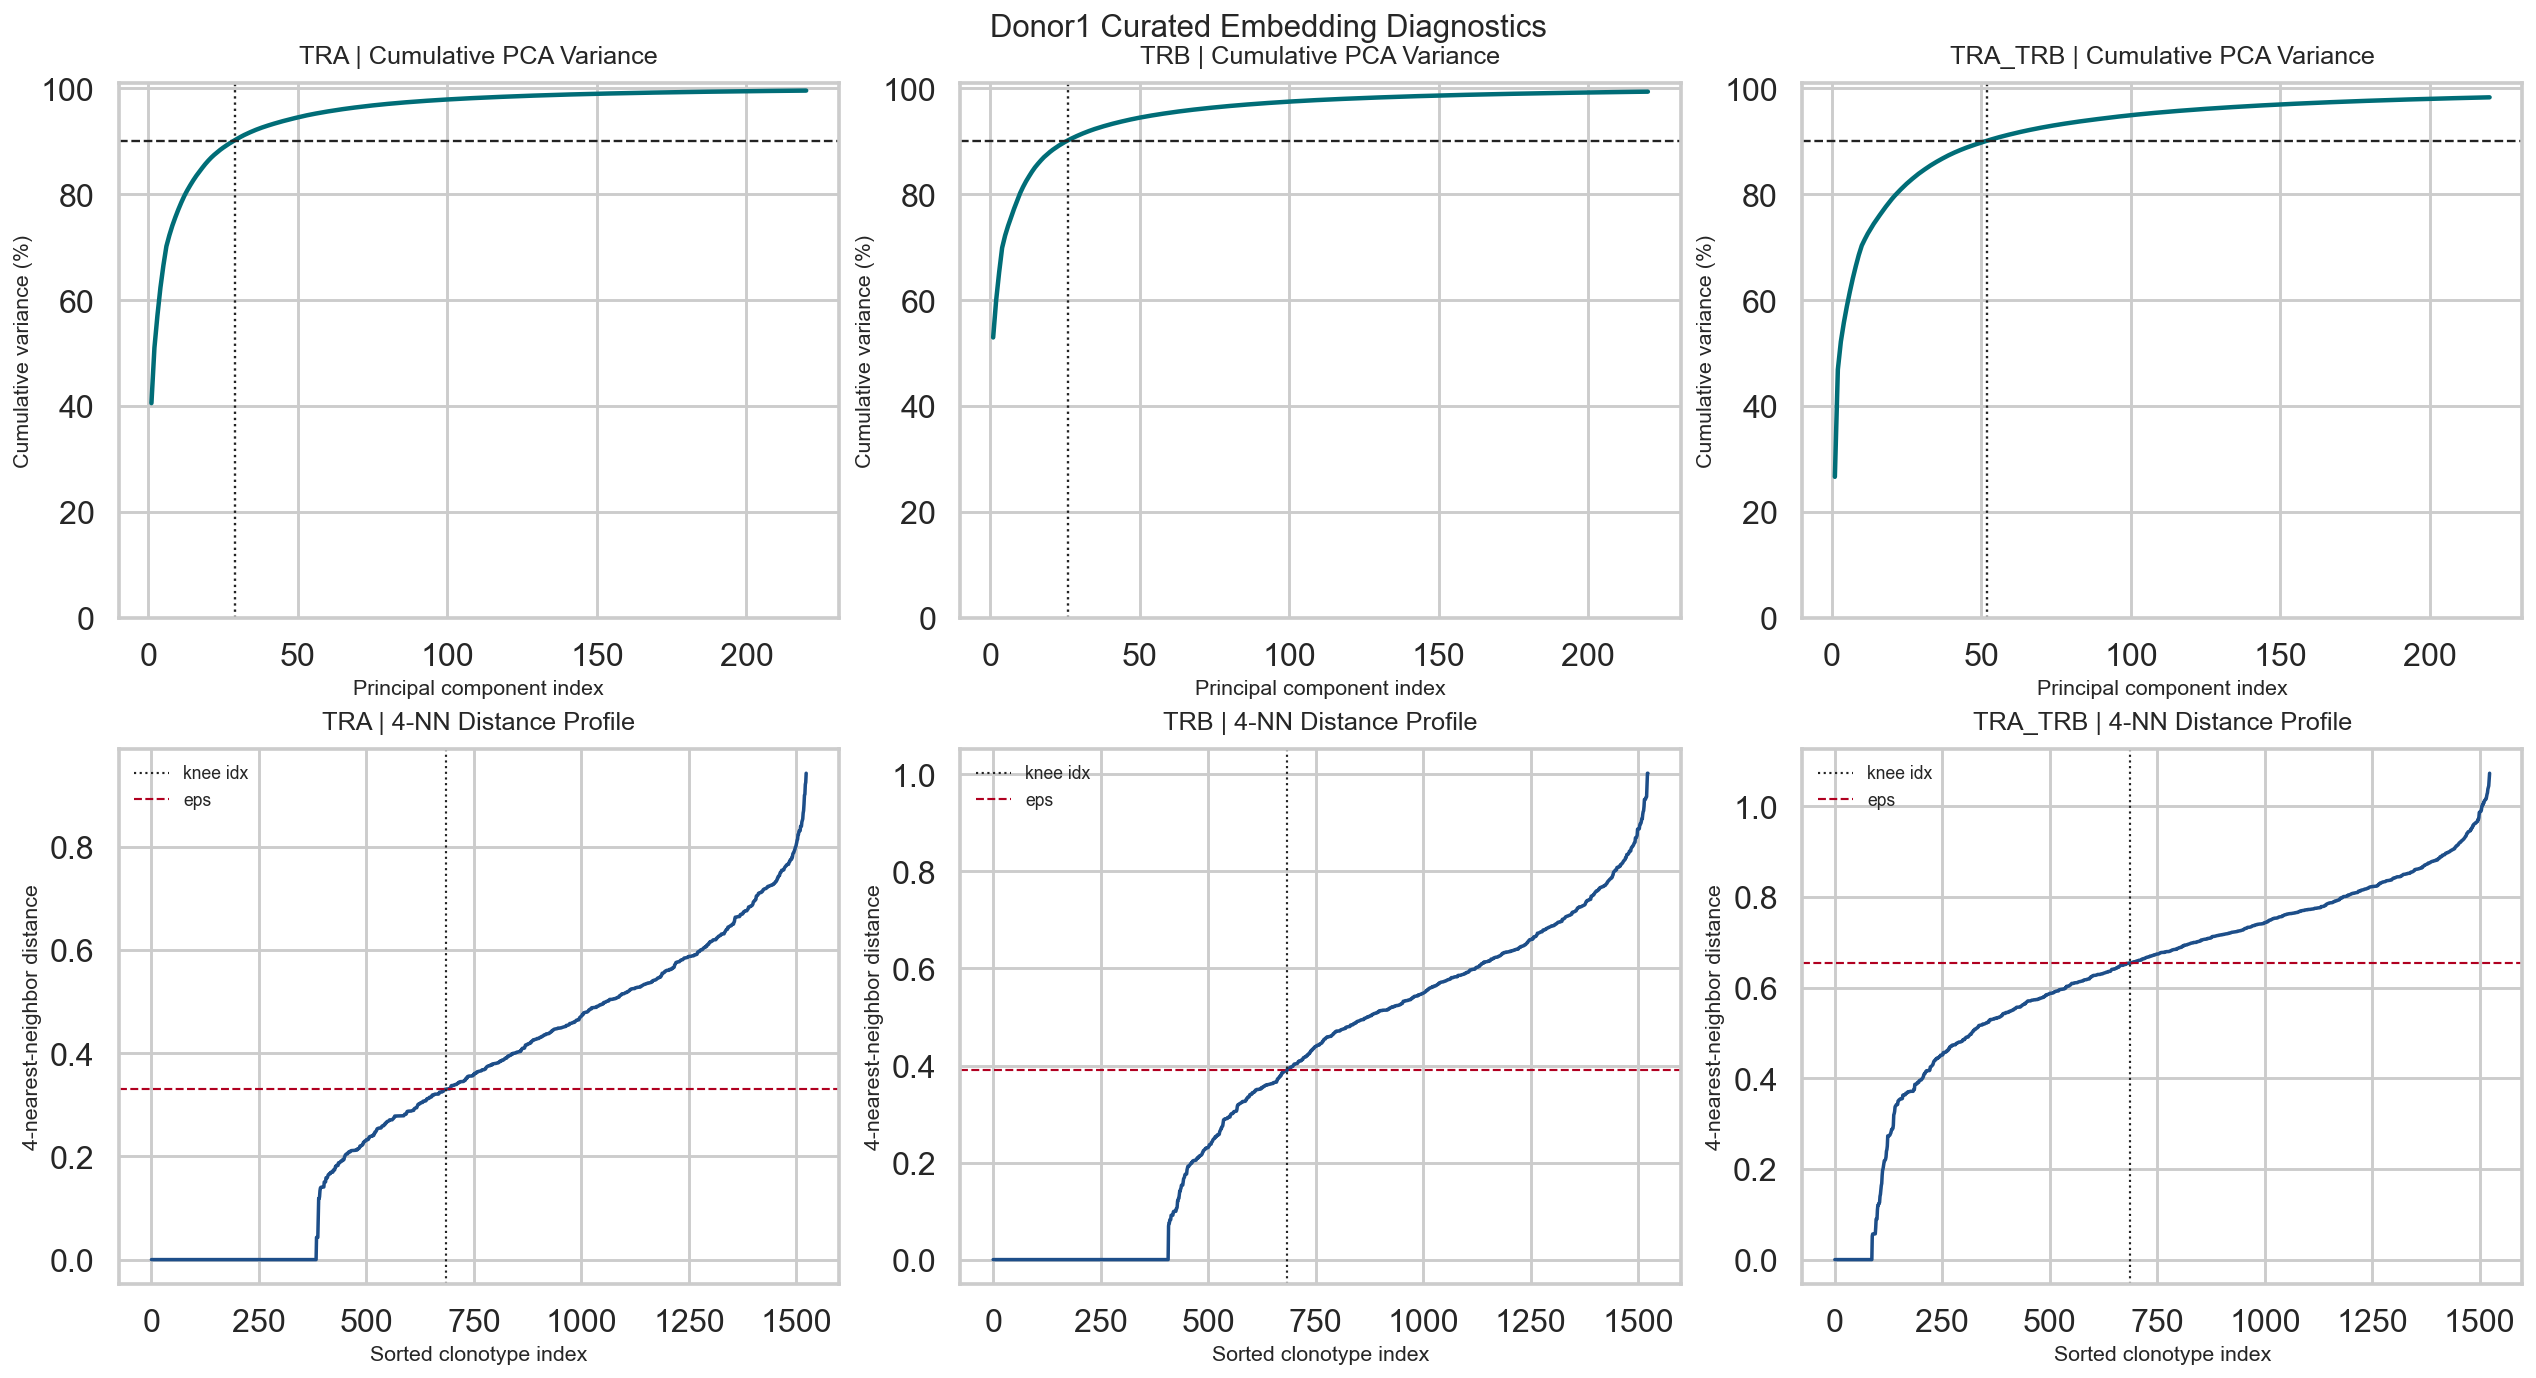

In [6]:
# Plot cumulative PCA variance and k-nearest-neighbor distance curves for eps selection.
fig, axes = plt.subplots(2, 3, figsize=(18, 9.5), constrained_layout=True)

for col, mode in enumerate(['TRA', 'TRB', 'TRA_TRB']):
    analysis = mode_results[mode]['analysis']

    max_show = min(220, len(analysis['cum']))
    ax = axes[0, col]
    ax.plot(np.arange(1, max_show + 1), analysis['cum'][:max_show] * 100, lw=2.3, color='#006d77')
    ax.axhline(90, color='#222222', ls='--', lw=1.2)
    ax.axvline(analysis['n_comp'], color='#222222', ls=':', lw=1.2)
    ax.set_title(f'{mode} | Cumulative PCA Variance', fontsize=13, pad=10)
    ax.set_xlabel('Principal component index', fontsize=11)
    ax.set_ylabel('Cumulative variance (%)', fontsize=11)
    ax.set_ylim(0, 101)

    kth = analysis['kth']
    ax = axes[1, col]
    ax.plot(kth, lw=1.8, color='#1d4e89')
    if analysis['knee_idx'] is not None:
        ax.axvline(int(analysis['knee_idx']), color='#222222', ls=':', lw=1.1, label='knee idx')
    ax.axhline(float(analysis['eps']), color='#b00020', ls='--', lw=1.1, label='eps')
    ax.set_title(f'{mode} | 4-NN Distance Profile', fontsize=13, pad=10)
    ax.set_xlabel('Sorted clonotype index', fontsize=11)
    ax.set_ylabel('4-nearest-neighbor distance', fontsize=11)
    ax.legend(loc='upper left', frameon=False, fontsize=9)

fig.suptitle('Donor1 Curated Embedding Diagnostics', fontsize=16, y=1.02)
plt.show()

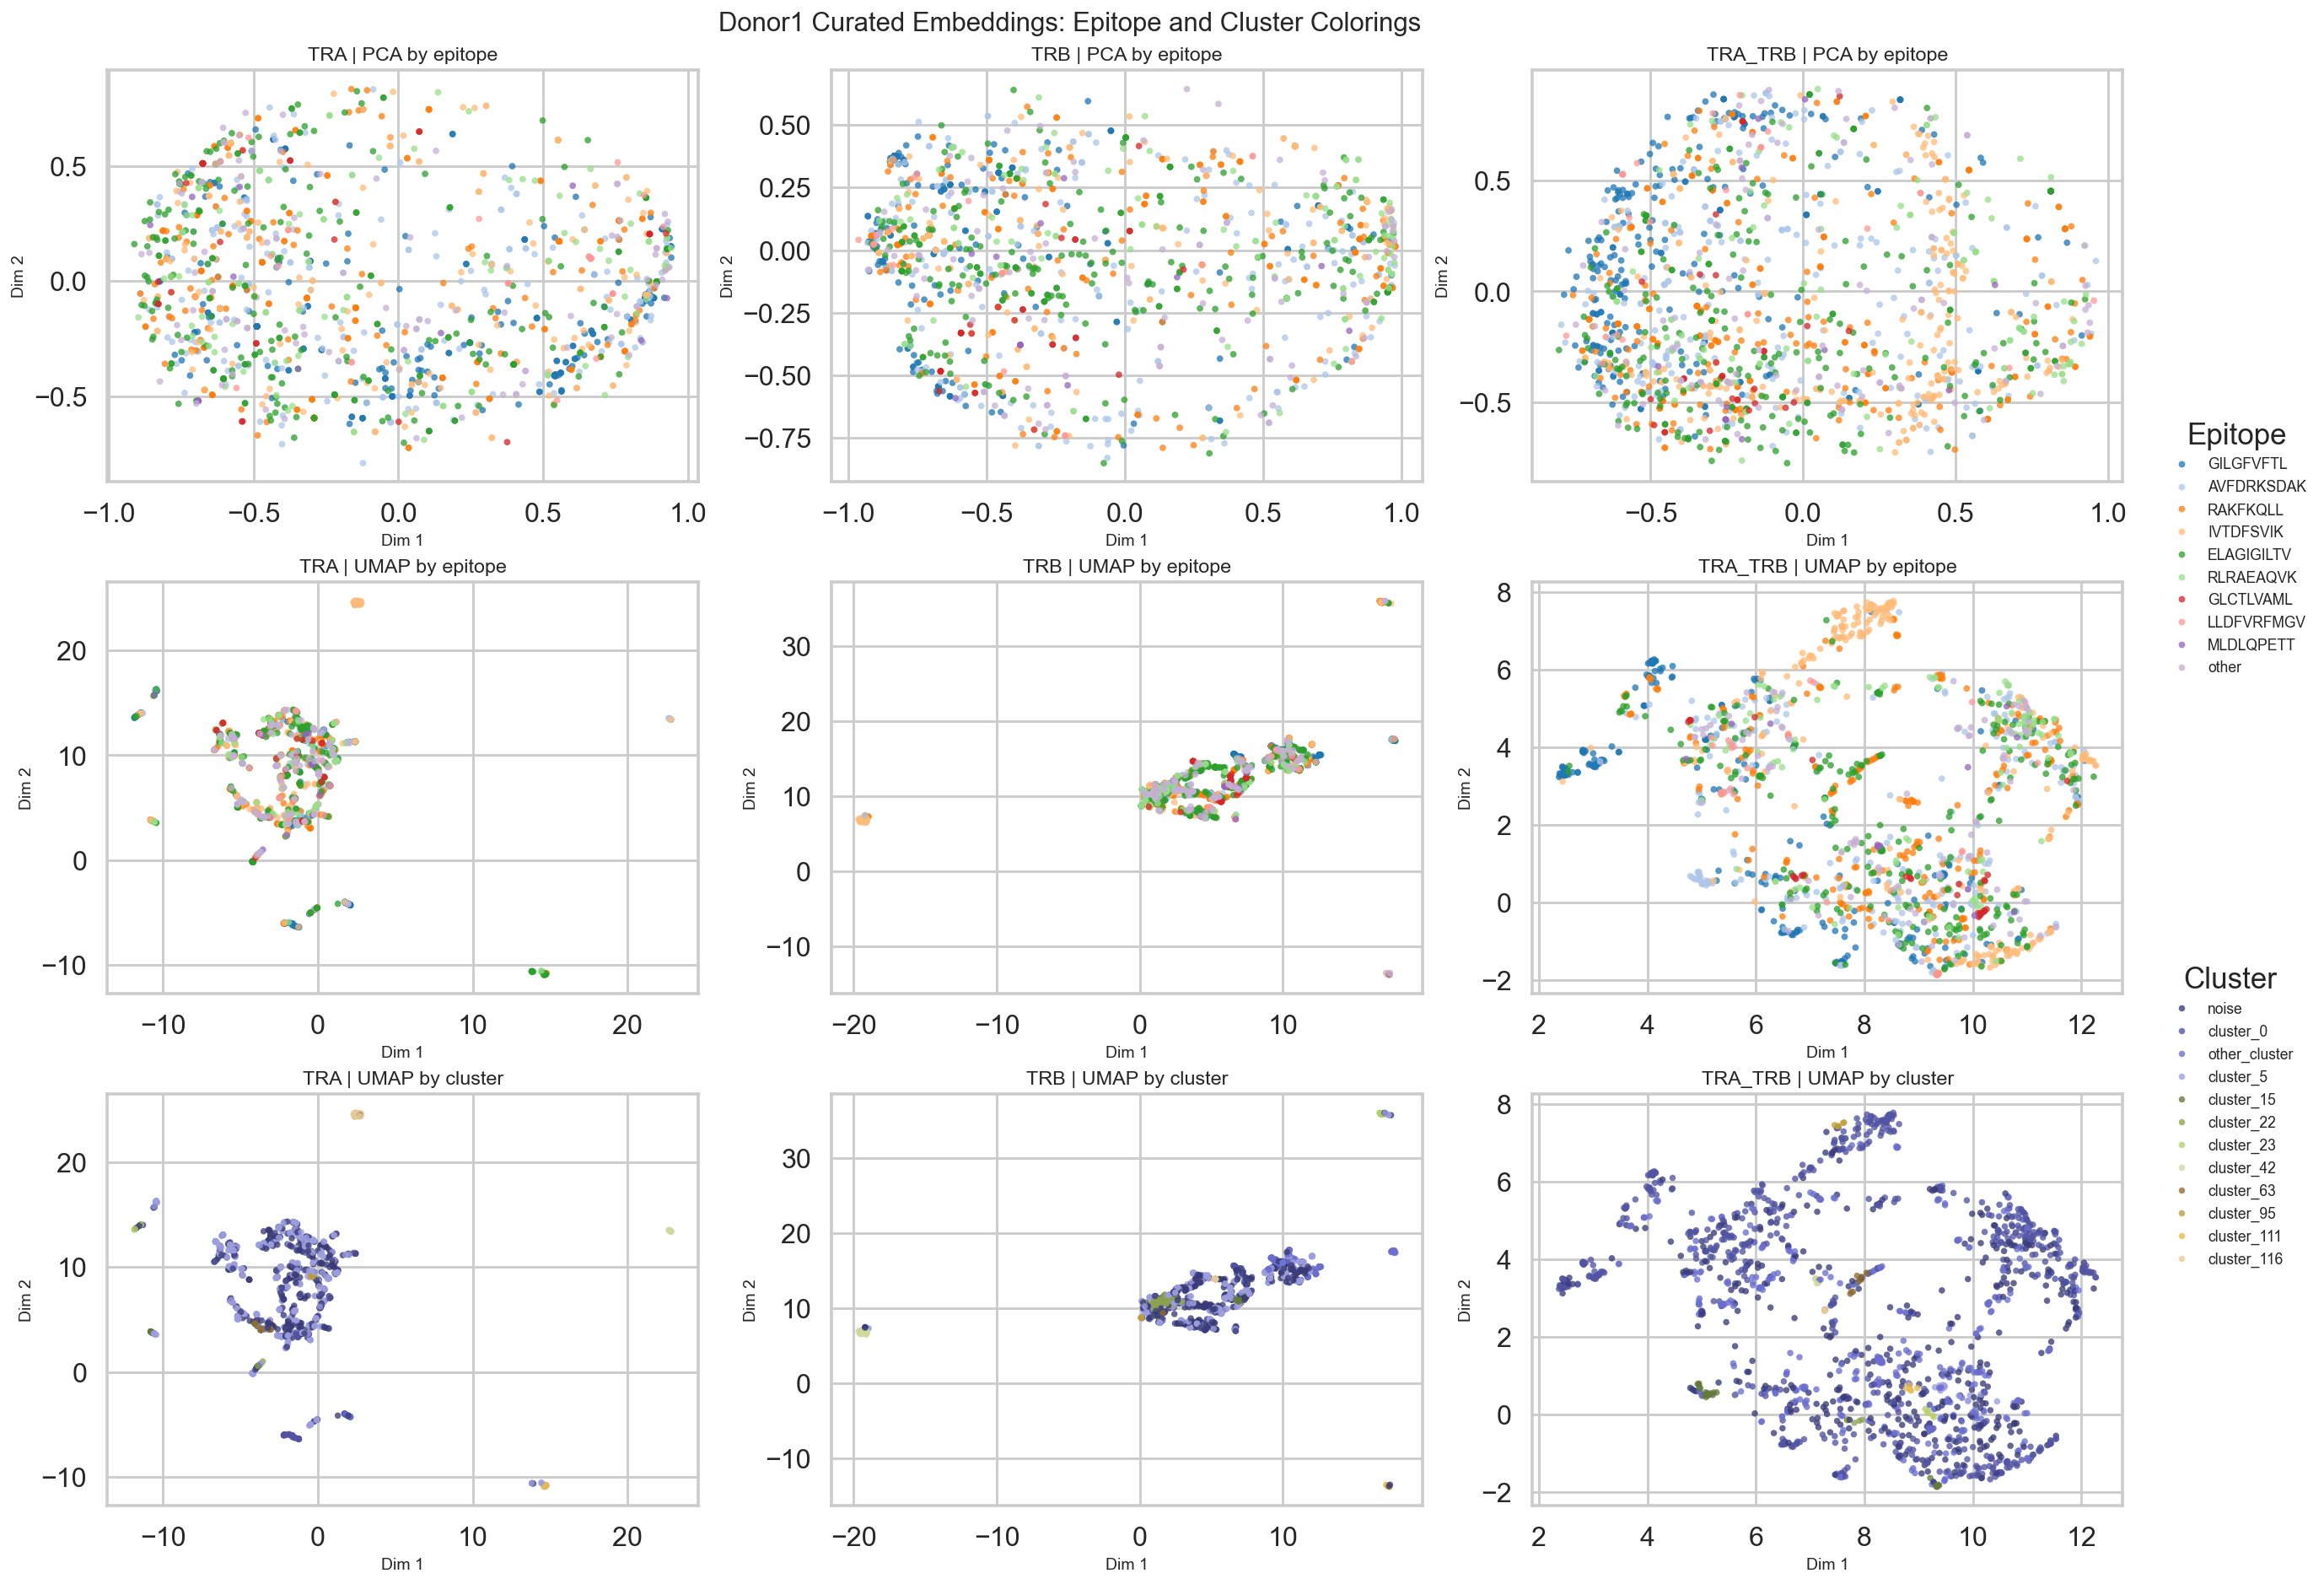

In [7]:
# Plot PCA/UMAP projections colored by epitope and by cluster assignments.
def _make_plot_frame(coords, labels, clusters):
    return pl.DataFrame({
        'x': coords[:, 0],
        'y': coords[:, 1],
        'epitope': labels,
        'cluster': clusters.astype(int),
    }).with_columns(
        pl.when(pl.col('cluster') == -1)
        .then(pl.lit('noise'))
        .otherwise(pl.format('cluster_{}', pl.col('cluster')))
        .alias('cluster_label')
    )


def _plot_by_epitope(ax, frame, title):
    top_labels = (
        frame.group_by('epitope').len().sort('len', descending=True).head(10).get_column('epitope').to_list()
    )
    display_frame = frame.with_columns(
        pl.when(pl.col('epitope').is_in(top_labels)).then(pl.col('epitope')).otherwise(pl.lit('other')).alias('epitope_disp')
    )
    sns.scatterplot(
        data=display_frame.to_pandas(),
        x='x',
        y='y',
        hue='epitope_disp',
        palette='tab20',
        s=16,
        alpha=0.76,
        linewidth=0,
        ax=ax,
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Dim 1', fontsize=10)
    ax.set_ylabel('Dim 2', fontsize=10)


def _plot_by_cluster(ax, frame, title):
    top_clusters = (
        frame.filter(pl.col('cluster') != -1)
        .group_by('cluster_label')
        .len()
        .sort('len', descending=True)
        .head(10)
        .get_column('cluster_label')
        .to_list()
    )
    display_frame = frame.with_columns(
        pl.when((pl.col('cluster_label').is_in(top_clusters)) | (pl.col('cluster_label') == 'noise'))
        .then(pl.col('cluster_label'))
        .otherwise(pl.lit('other_cluster'))
        .alias('cluster_disp')
    )
    sns.scatterplot(
        data=display_frame.to_pandas(),
        x='x',
        y='y',
        hue='cluster_disp',
        palette='tab20b',
        s=15,
        alpha=0.78,
        linewidth=0,
        ax=ax,
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Dim 1', fontsize=10)
    ax.set_ylabel('Dim 2', fontsize=10)


fig, axes = plt.subplots(3, 3, figsize=(18, 13), constrained_layout=True)
for col, mode in enumerate(['TRA', 'TRB', 'TRA_TRB']):
    pca_coords = mode_results[mode]['analysis']['X_pca'][:, :2]
    umap_coords = mode_results[mode]['X_umap']
    clusters = mode_results[mode]['analysis']['clusters']

    pca_frame = _make_plot_frame(pca_coords, balanced_labels, clusters)
    umap_frame = _make_plot_frame(umap_coords, balanced_labels, clusters)

    _plot_by_epitope(axes[0, col], pca_frame, f'{mode} | PCA by epitope')
    _plot_by_epitope(axes[1, col], umap_frame, f'{mode} | UMAP by epitope')
    _plot_by_cluster(axes[2, col], umap_frame, f'{mode} | UMAP by cluster')

for r in range(3):
    for c in range(3):
        if axes[r, c].legend_ is not None:
            axes[r, c].legend_.remove()

handles_e, labels_e = axes[0, 2].get_legend_handles_labels()
handles_c, labels_c = axes[2, 2].get_legend_handles_labels()
fig.legend(handles_e, labels_e, title='Epitope', loc='center left', bbox_to_anchor=(1.01, 0.67), frameon=False, fontsize=9)
fig.legend(handles_c, labels_c, title='Cluster', loc='center left', bbox_to_anchor=(1.01, 0.30), frameon=False, fontsize=9)
fig.suptitle('Donor1 Curated Embeddings: Epitope and Cluster Colorings', fontsize=16, y=1.02)
plt.show()

In [8]:
# Display epitope-level classification score tables by mode with pandas styling.
for mode in ['TRA', 'TRB', 'TRA_TRB']:
    print(f'\n{mode} epitope classification scores (top 15 by support):')
    display_df = (
        epitope_scores
        .filter(pl.col('mode') == mode)
        .sort(['support', 'f1'], descending=[True, True])
        .head(15)
    )
    pd_df = display_df.to_pandas()
    display(
        pd_df.style
        .background_gradient(subset=['precision', 'recall', 'f1'], cmap='YlOrRd')
        .format({'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}'})
    )

print('\nGlobal mode summary with clustering and classification metrics:')
summary_pd = mode_summary.sort('weighted_f1', descending=True).to_pandas()
display(
    summary_pd.style
    .background_gradient(subset=['purity', 'consistency_70', 'weighted_f1', 'accuracy'], cmap='YlGnBu')
    .format(precision=3)
)


TRA epitope classification scores (top 15 by support):


,mode,epitope,precision,recall,f1,support
0,TRA,GILGFVFTL,0.734,0.708,0.721,250
1,TRA,IVTDFSVIK,0.851,0.592,0.698,250
2,TRA,RAKFKQLL,0.740,0.636,0.684,250
3,TRA,ELAGIGILTV,0.634,0.540,0.583,250
4,TRA,AVFDRKSDAK,0.729,0.484,0.582,250
5,TRA,RLRAEAQVK,0.833,0.381,0.523,105
6,TRA,other,0.929,0.299,0.452,87
7,TRA,GLCTLVAML,0.652,0.484,0.556,31
8,TRA,LLDFVRFMGV,0.750,0.556,0.638,27
9,TRA,MLDLQPETT,0.000,0.000,0.000,13



TRB epitope classification scores (top 15 by support):


,mode,epitope,precision,recall,f1,support
0,TRB,IVTDFSVIK,0.911,0.652,0.760,250
1,TRB,GILGFVFTL,0.643,0.772,0.702,250
2,TRB,RAKFKQLL,0.603,0.632,0.617,250
3,TRB,AVFDRKSDAK,0.728,0.440,0.549,250
4,TRB,ELAGIGILTV,0.869,0.372,0.521,250
5,TRB,RLRAEAQVK,0.939,0.295,0.449,105
6,TRB,other,0.957,0.253,0.400,87
7,TRB,GLCTLVAML,0.955,0.677,0.792,31
8,TRB,LLDFVRFMGV,0.700,0.259,0.378,27
9,TRB,MLDLQPETT,0.833,0.385,0.526,13



TRA_TRB epitope classification scores (top 15 by support):


,mode,epitope,precision,recall,f1,support
0,TRA_TRB,AVFDRKSDAK,0.809,0.372,0.510,250
1,TRA_TRB,RAKFKQLL,0.914,0.340,0.496,250
2,TRA_TRB,IVTDFSVIK,0.305,0.844,0.448,250
3,TRA_TRB,ELAGIGILTV,0.917,0.264,0.410,250
4,TRA_TRB,GILGFVFTL,0.760,0.152,0.253,250
5,TRA_TRB,RLRAEAQVK,0.917,0.314,0.468,105
6,TRA_TRB,other,0.893,0.287,0.435,87
7,TRA_TRB,GLCTLVAML,0.615,0.258,0.364,31
8,TRA_TRB,LLDFVRFMGV,0.846,0.407,0.550,27
9,TRA_TRB,MLDLQPETT,1.000,0.308,0.471,13



Global mode summary with clustering and classification metrics:


,mode,n_records,embed_time_s,pcs_90pct,eps,clusters,retention,purity,consistency_70,macro_f1,weighted_f1,accuracy
0,TRA,1524,0.020,29,0.331,244,0.741,0.789,0.586,0.479,0.623,0.550
1,TRB,1524,0.021,26,0.391,209,0.719,0.851,0.703,0.500,0.600,0.528
2,TRA_TRB,1524,0.044,52,0.655,163,0.732,0.904,0.810,0.367,0.425,0.377
